In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load processed training data
df = pd.read_csv("../data/processed/train_processed.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (400, 39)


In [25]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(400, 39)

Column Names:
['num__soil_moisture_%', 'num__soil_pH', 'num__temperature_C', 'num__rainfall_mm', 'num__humidity_%', 'num__sunlight_hours', 'num__pesticide_usage_ml', 'num__total_days', 'num__latitude', 'num__longitude', 'num__NDVI_index', 'num__sowing_month', 'num__sowing_day', 'num__observation_month', 'num__observation_day', 'num__days_since_sowing', 'num__crop_cycle_progress', 'cat__region_Central USA', 'cat__region_East Africa', 'cat__region_North India', 'cat__region_South India', 'cat__region_South USA', 'cat__crop_type_Cotton', 'cat__crop_type_Maize', 'cat__crop_type_Rice', 'cat__crop_type_Soybean', 'cat__crop_type_Wheat', 'cat__irrigation_type_Drip', 'cat__irrigation_type_Manual', 'cat__irrigation_type_Sprinkler', 'cat__irrigation_type_Unknown', 'cat__fertilizer_type_Inorganic', 'cat__fertilizer_type_Mixed', 'cat__fertilizer_type_Organic', 'cat__crop_disease_status_Mild', 'cat__crop_disease_status_Moderate', 'cat__crop_disease_status_Severe', 'cat__cro

In [26]:
# Check missing values
missing_values = df.isnull().sum()

print("Total missing values:", missing_values.sum())

# Show columns having missing values
if missing_values.sum() > 0:
    print("\nColumns with missing values:")
    print(missing_values[missing_values > 0])
else:
    print("No missing values found!")

# Check duplicate rows
duplicates = df.duplicated().sum()

print("\nNumber of duplicate rows:", duplicates)

if duplicates == 0:
    print("No duplicate rows found!")
else:
    print("Duplicate rows found!")

Total missing values: 0
No missing values found!

Number of duplicate rows: 0
No duplicate rows found!


In [27]:
# Target variable
TARGET = "yield_kg_per_hectare"

# Numerical features
numerical_features = [
    col for col in df.columns
    if col.startswith("num__")
]

# One-hot encoded categorical features
categorical_features = [
    col for col in df.columns
    if col.startswith("cat__")
]

print("Target variable:")
print(TARGET)

print("\nNumber of numerical features:", len(numerical_features))
print("Number of encoded categorical features:", len(categorical_features))

print("\nNumerical features:")
print(numerical_features)

print("\nEncoded categorical features:")
print(categorical_features)

Target variable:
yield_kg_per_hectare

Number of numerical features: 17
Number of encoded categorical features: 21

Numerical features:
['num__soil_moisture_%', 'num__soil_pH', 'num__temperature_C', 'num__rainfall_mm', 'num__humidity_%', 'num__sunlight_hours', 'num__pesticide_usage_ml', 'num__total_days', 'num__latitude', 'num__longitude', 'num__NDVI_index', 'num__sowing_month', 'num__sowing_day', 'num__observation_month', 'num__observation_day', 'num__days_since_sowing', 'num__crop_cycle_progress']

Encoded categorical features:
['cat__region_Central USA', 'cat__region_East Africa', 'cat__region_North India', 'cat__region_South India', 'cat__region_South USA', 'cat__crop_type_Cotton', 'cat__crop_type_Maize', 'cat__crop_type_Rice', 'cat__crop_type_Soybean', 'cat__crop_type_Wheat', 'cat__irrigation_type_Drip', 'cat__irrigation_type_Manual', 'cat__irrigation_type_Sprinkler', 'cat__irrigation_type_Unknown', 'cat__fertilizer_type_Inorganic', 'cat__fertilizer_type_Mixed', 'cat__fertilizer_t

In [28]:
print("Crop Yield Statistics")
print("=" * 40)

print(df[TARGET].describe())

print("\nAdditional Statistics:")
print("Mean   :", round(df[TARGET].mean(), 2), "kg/hectare")
print("Median :", round(df[TARGET].median(), 2), "kg/hectare")
print("Std Dev:", round(df[TARGET].std(), 2), "kg/hectare")
print("Minimum:", round(df[TARGET].min(), 2), "kg/hectare")
print("Maximum:", round(df[TARGET].max(), 2), "kg/hectare")

Crop Yield Statistics
count     400.000000
mean     4037.775650
std      1174.194159
min      2023.560000
25%      3020.495000
50%      4071.690000
75%      5076.812500
max      5998.290000
Name: yield_kg_per_hectare, dtype: float64

Additional Statistics:
Mean   : 4037.78 kg/hectare
Median : 4071.69 kg/hectare
Std Dev: 1174.19 kg/hectare
Minimum: 2023.56 kg/hectare
Maximum: 5998.29 kg/hectare


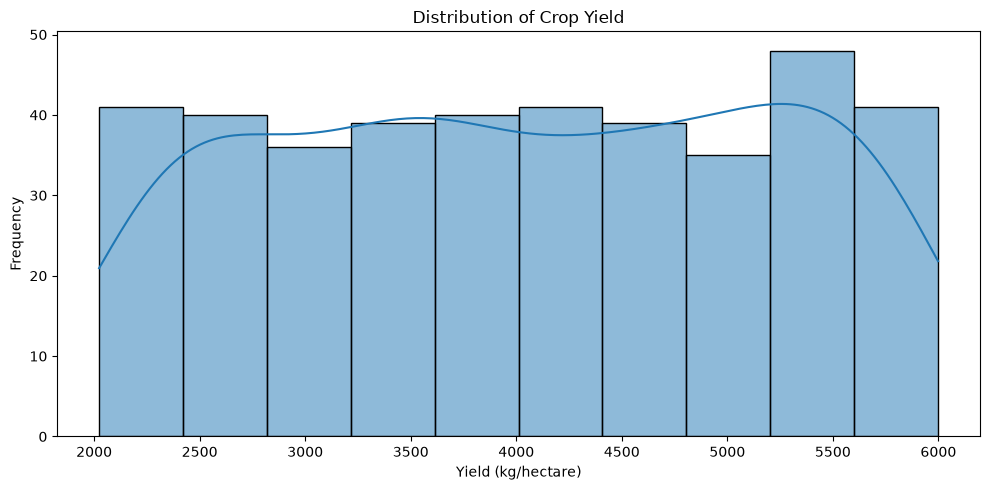

In [29]:
plt.figure(figsize=(10, 5))

sns.histplot(
    df[TARGET],
    kde=True
)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (kg/hectare)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

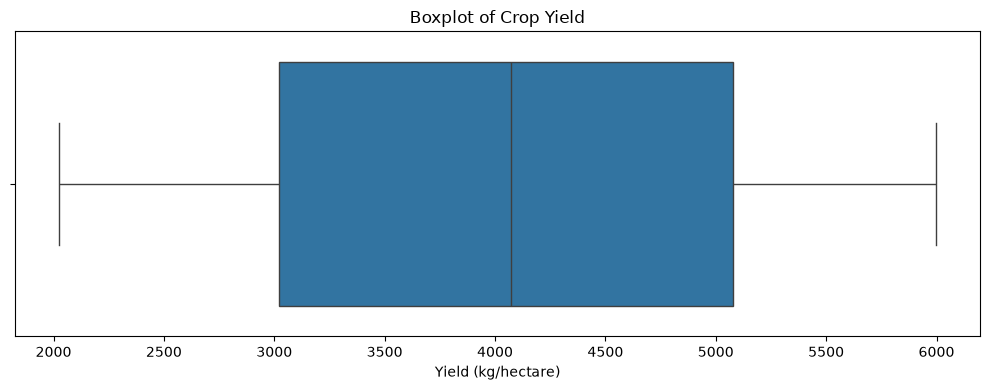

In [30]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df[TARGET])

plt.title("Boxplot of Crop Yield")
plt.xlabel("Yield (kg/hectare)")

plt.tight_layout()
plt.show()

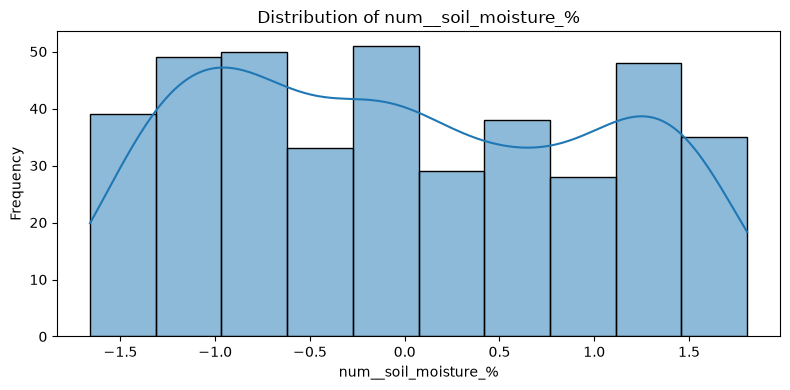

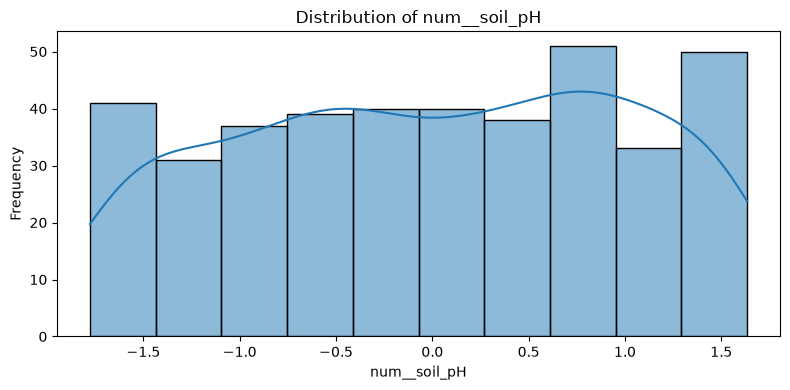

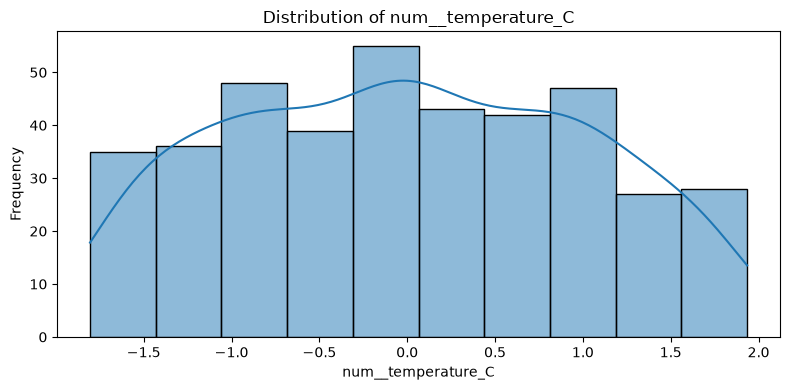

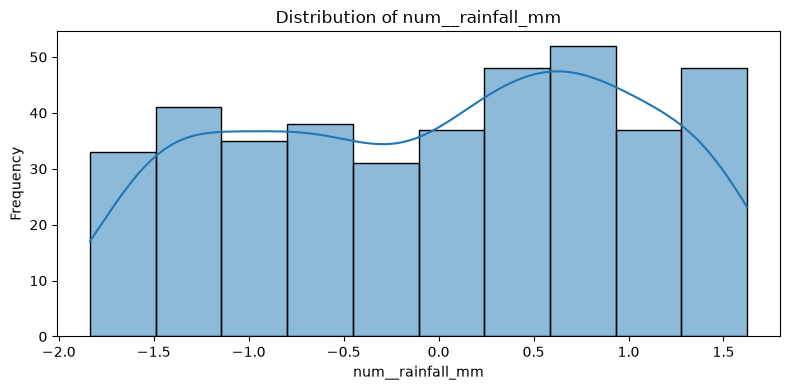

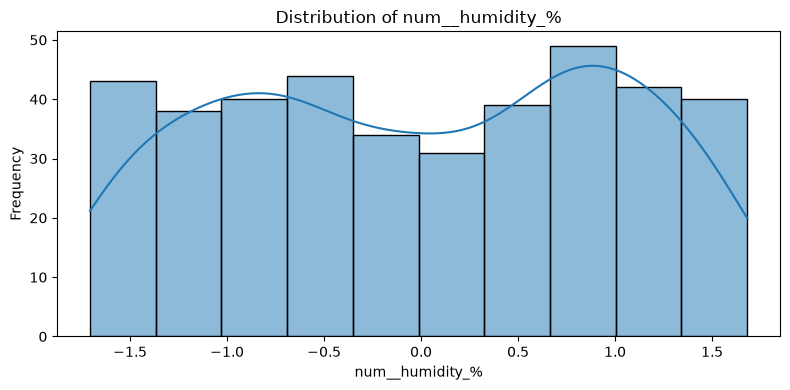

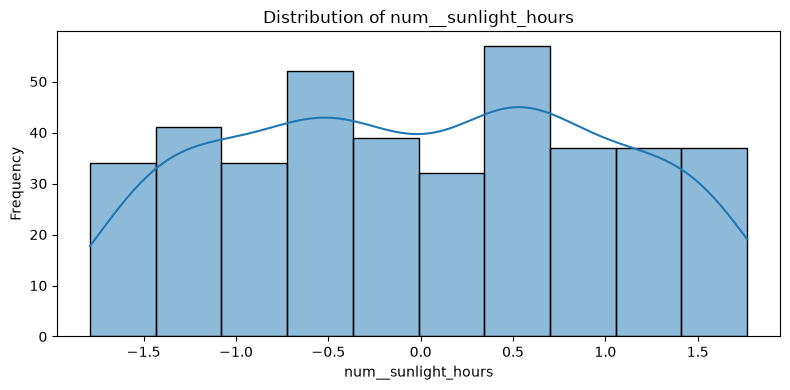

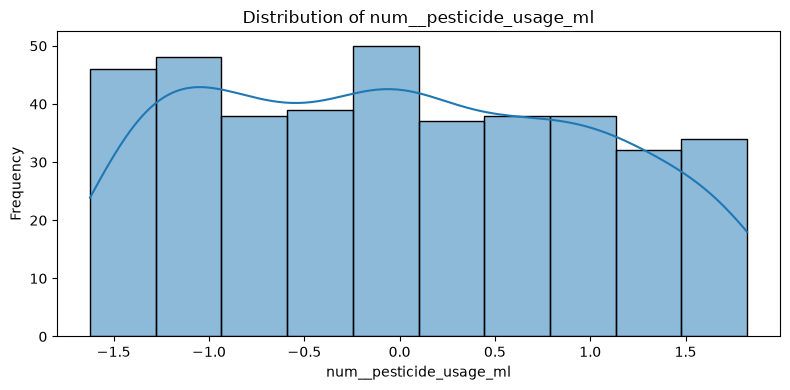

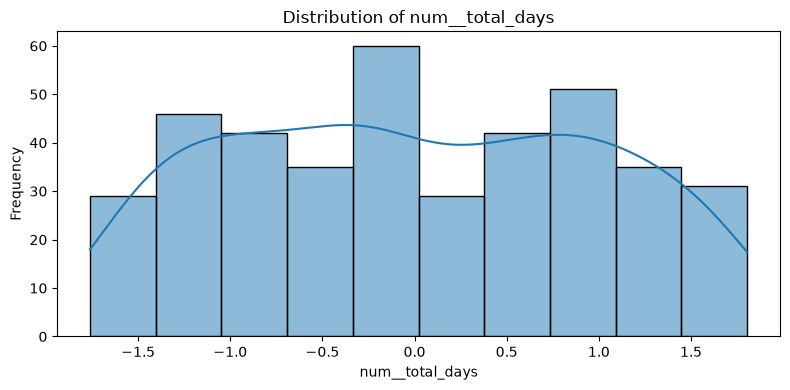

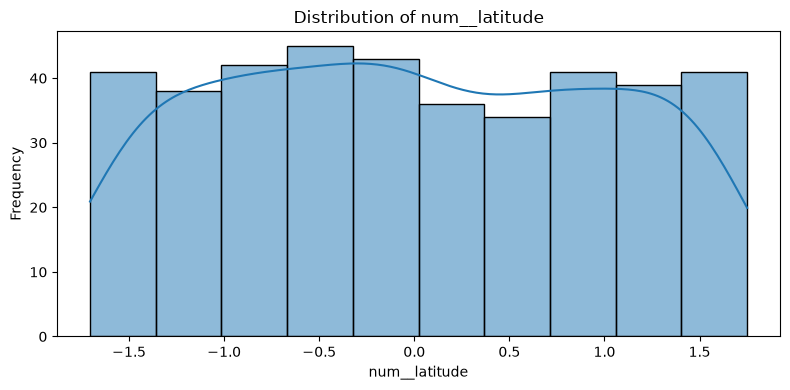

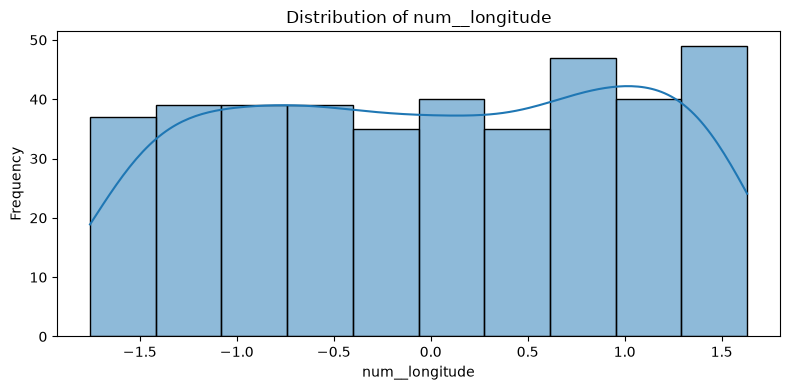

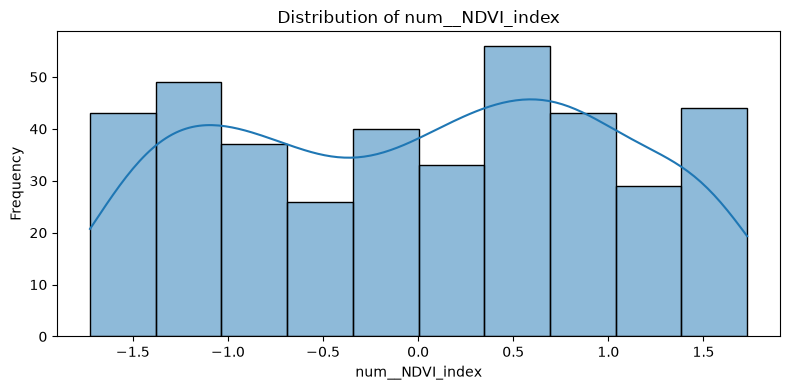

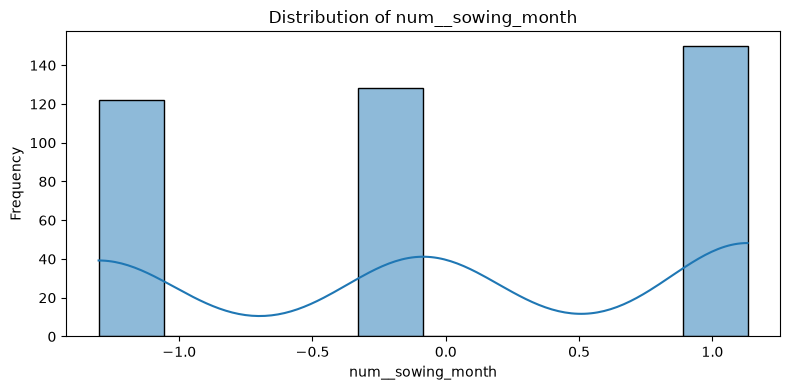

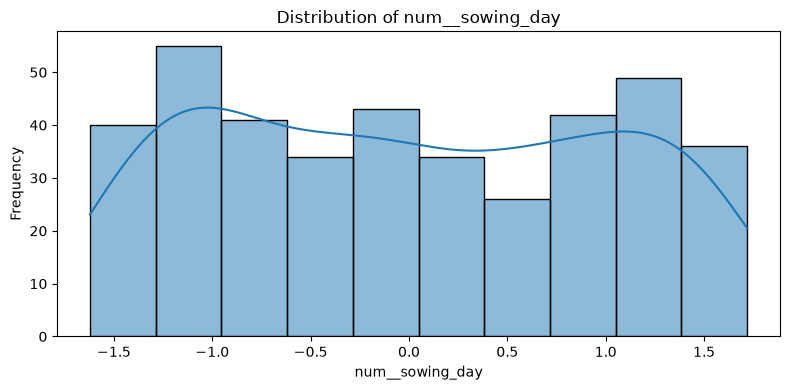

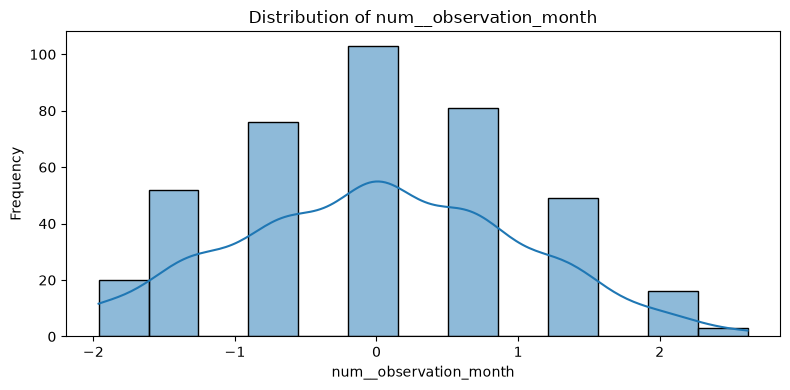

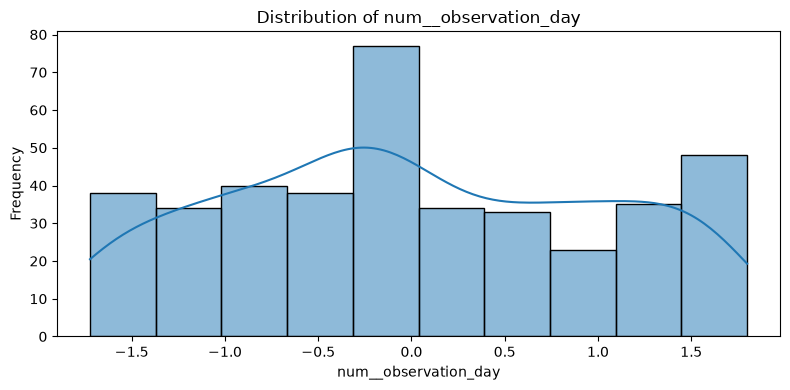

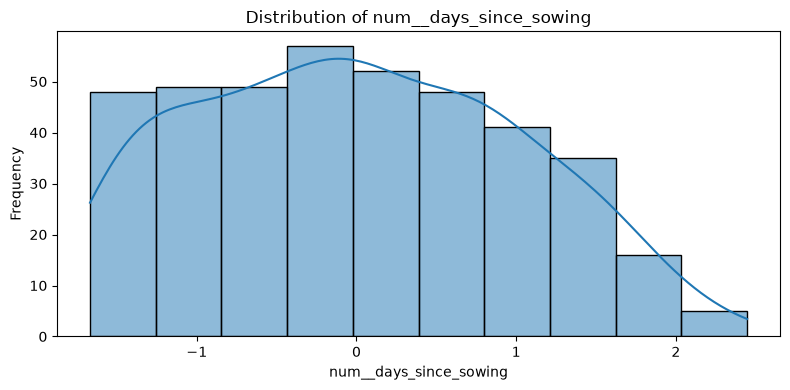

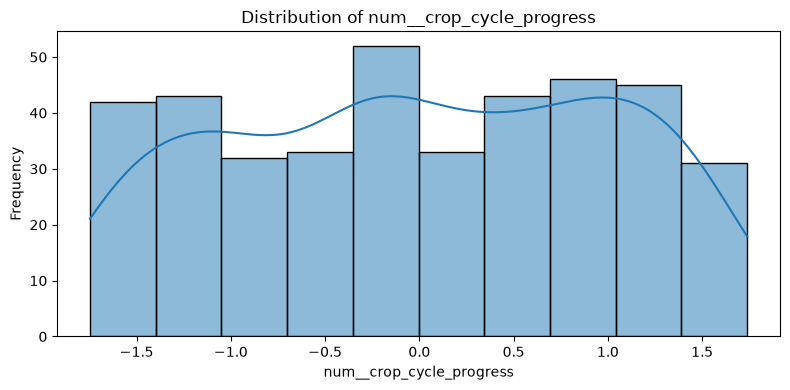

In [31]:
for feature in numerical_features:

    plt.figure(figsize=(8, 4))

    sns.histplot(
        data=df,
        x=feature,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [32]:
correlations = (
    df[numerical_features + [TARGET]]
    .corr()[TARGET]
    .sort_values(ascending=False)
)

print("Correlation of Numerical Features with Crop Yield")
print("=" * 55)

display(correlations)

Correlation of Numerical Features with Crop Yield


yield_kg_per_hectare        1.000000
num__pesticide_usage_ml     0.059906
num__NDVI_index             0.059072
num__soil_pH                0.040621
num__crop_cycle_progress    0.027484
num__total_days             0.018986
num__days_since_sowing      0.018970
num__temperature_C          0.018301
num__observation_month      0.015748
num__humidity_%             0.013654
num__sunlight_hours         0.004459
num__sowing_day            -0.010183
num__longitude             -0.013406
num__sowing_month          -0.014209
num__latitude              -0.020471
num__observation_day       -0.054263
num__rainfall_mm           -0.068425
num__soil_moisture_%       -0.110451
Name: yield_kg_per_hectare, dtype: float64

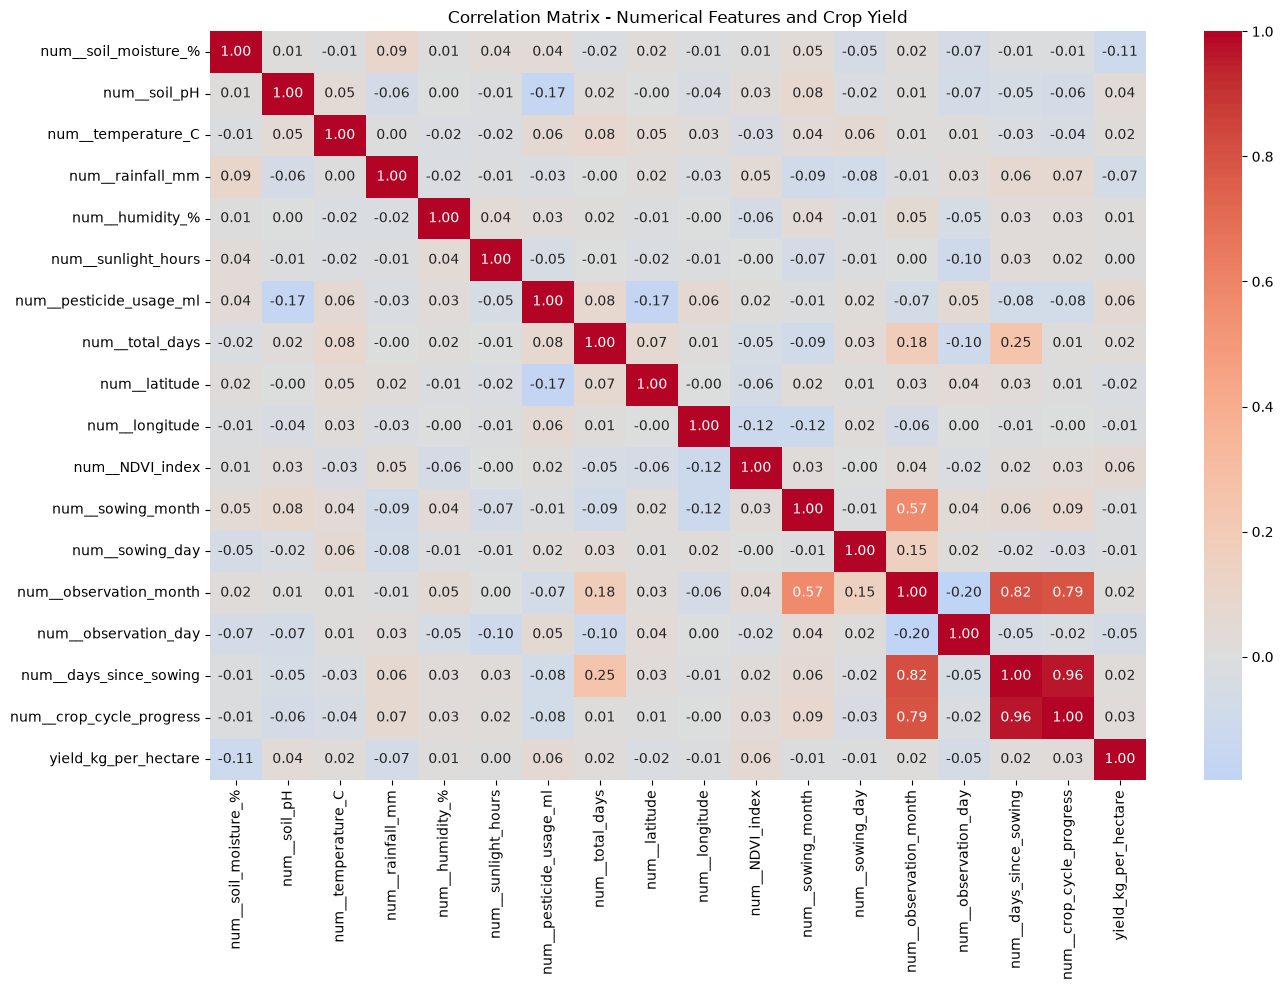

In [33]:
corr_matrix = df[numerical_features + [TARGET]].corr()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - Numerical Features and Crop Yield")
plt.tight_layout()
plt.show()

Average Yield by Crop
Soybean    4285.368778
Wheat      4050.167564
Maize      3988.334819
Cotton     3960.876023
Rice       3834.838033
dtype: float64


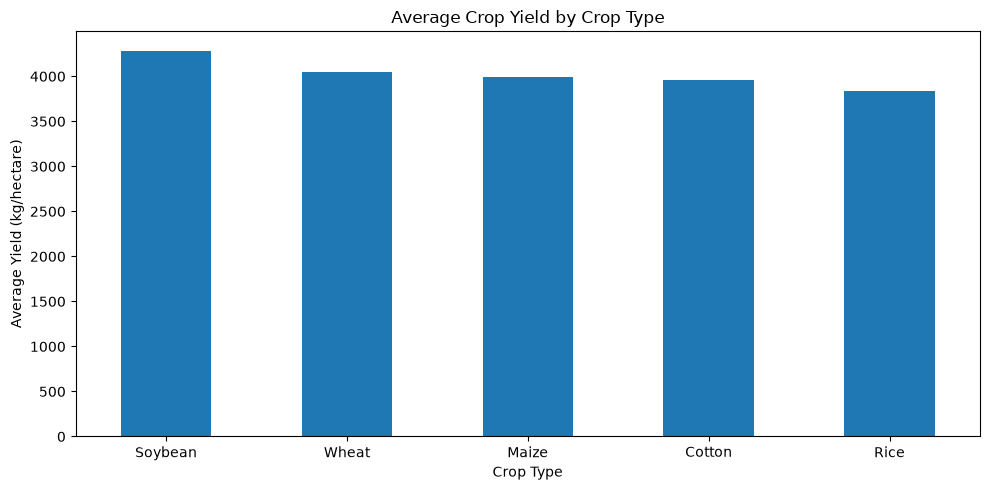

In [35]:
crop_columns = [
    "cat__crop_type_Cotton",
    "cat__crop_type_Maize",
    "cat__crop_type_Rice",
    "cat__crop_type_Soybean",
    "cat__crop_type_Wheat"
]

crop_yield = {}

for column in crop_columns:
    crop_name = column.replace("cat__crop_type_", "")
    
    crop_data = df[df[column] == 1]
    
    crop_yield[crop_name] = crop_data[TARGET].mean()

crop_yield = pd.Series(crop_yield).sort_values(ascending=False)

print("Average Yield by Crop")
print("=" * 35)
print(crop_yield)

plt.figure(figsize=(10, 5))

crop_yield.plot(kind="bar")

plt.title("Average Crop Yield by Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Average Yield (kg/hectare)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Average Yield by Region
South India    4182.933462
East Africa    4084.993165
North India    4005.176104
Central USA    3976.988409
South USA      3945.557051
dtype: float64


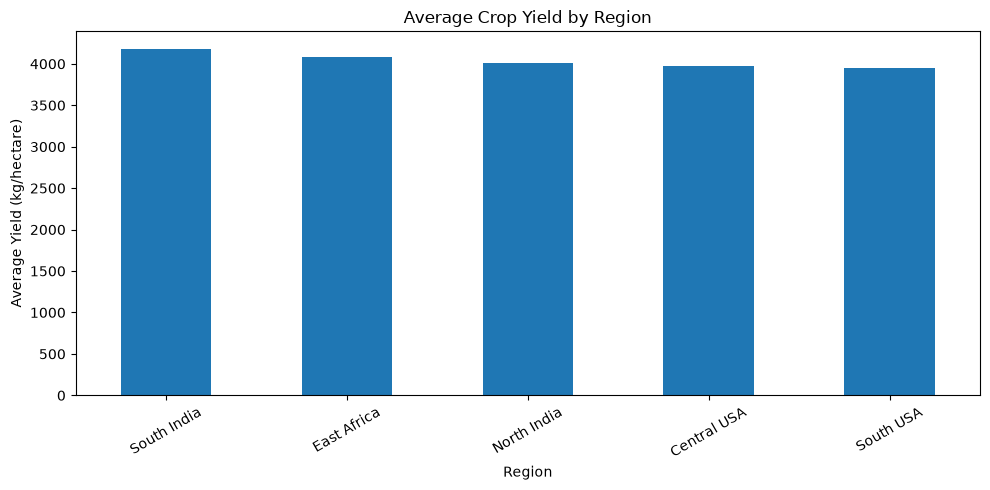

In [37]:
region_columns = [
    "cat__region_Central USA",
    "cat__region_East Africa",
    "cat__region_North India",
    "cat__region_South India",
    "cat__region_South USA"
]

region_yield = {}

for column in region_columns:
    region_name = column.replace("cat__region_", "")
    
    region_data = df[df[column] == 1]
    
    region_yield[region_name] = region_data[TARGET].mean()

region_yield = pd.Series(region_yield).sort_values(ascending=False)

print("Average Yield by Region")
print("=" * 35)
print(region_yield)

plt.figure(figsize=(10, 5))

region_yield.plot(kind="bar")

plt.title("Average Crop Yield by Region")
plt.xlabel("Region")
plt.ylabel("Average Yield (kg/hectare)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

Average Yield by Irrigation Type
Drip         4099.133478
Sprinkler    4067.585417
Manual       4062.692105
Unknown      3944.837863
dtype: float64


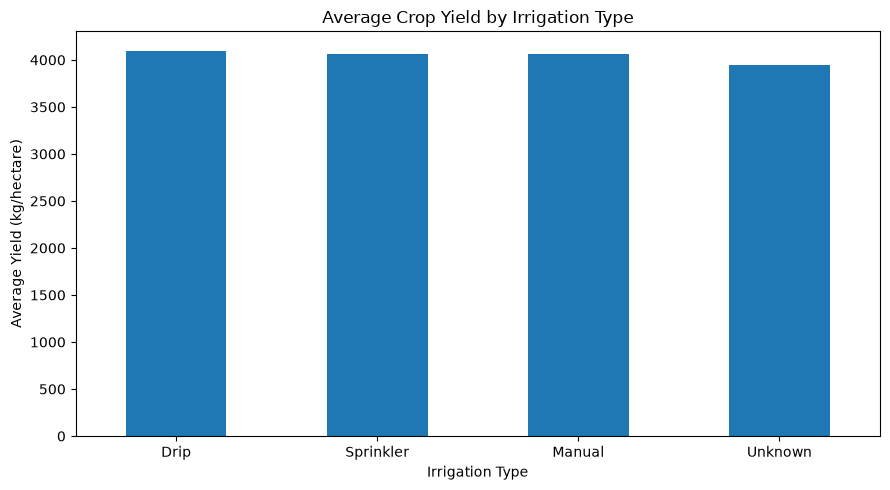

In [39]:
irrigation_columns = [
    "cat__irrigation_type_Drip",
    "cat__irrigation_type_Manual",
    "cat__irrigation_type_Sprinkler",
    "cat__irrigation_type_Unknown"
]

irrigation_yield = {}

for column in irrigation_columns:
    irrigation_name = column.replace("cat__irrigation_type_", "")
    
    irrigation_data = df[df[column] == 1]
    
    irrigation_yield[irrigation_name] = irrigation_data[TARGET].mean()

irrigation_yield = pd.Series(irrigation_yield).sort_values(ascending=False)

print("Average Yield by Irrigation Type")
print("=" * 40)
print(irrigation_yield)

plt.figure(figsize=(9, 5))

irrigation_yield.plot(kind="bar")

plt.title("Average Crop Yield by Irrigation Type")
plt.xlabel("Irrigation Type")
plt.ylabel("Average Yield (kg/hectare)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Average Yield by Fertilizer Type
Inorganic    4076.044769
Organic      4048.587910
Mixed        3990.541618
dtype: float64


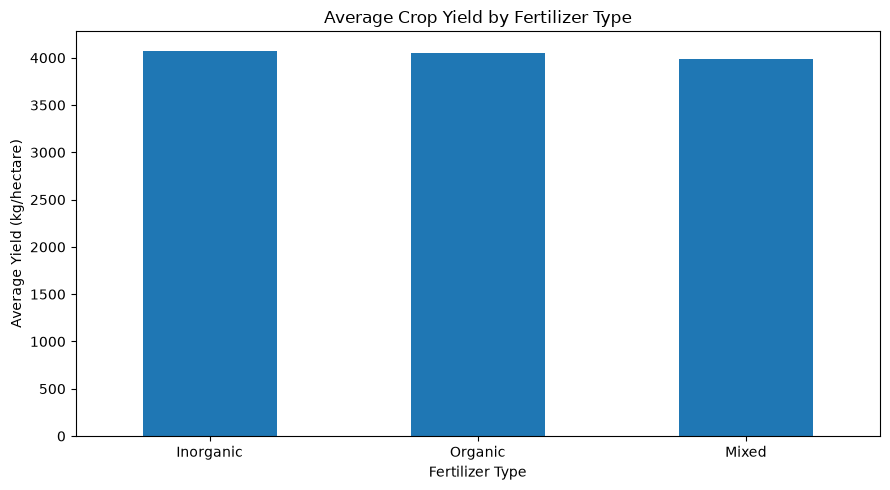

In [40]:
fertilizer_columns = [
    "cat__fertilizer_type_Inorganic",
    "cat__fertilizer_type_Mixed",
    "cat__fertilizer_type_Organic"
]

fertilizer_yield = {}

for column in fertilizer_columns:
    fertilizer_name = column.replace("cat__fertilizer_type_", "")
    
    fertilizer_data = df[df[column] == 1]
    
    fertilizer_yield[fertilizer_name] = fertilizer_data[TARGET].mean()

fertilizer_yield = pd.Series(fertilizer_yield).sort_values(ascending=False)

print("Average Yield by Fertilizer Type")
print("=" * 40)
print(fertilizer_yield)

# Visualization
plt.figure(figsize=(9, 5))

fertilizer_yield.plot(kind="bar")

plt.title("Average Crop Yield by Fertilizer Type")
plt.xlabel("Fertilizer Type")
plt.ylabel("Average Yield (kg/hectare)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Average Yield by Crop Disease Status
Mild        4155.847835
Unknown     4111.571584
Severe      3953.679266
Moderate    3933.045699
dtype: float64


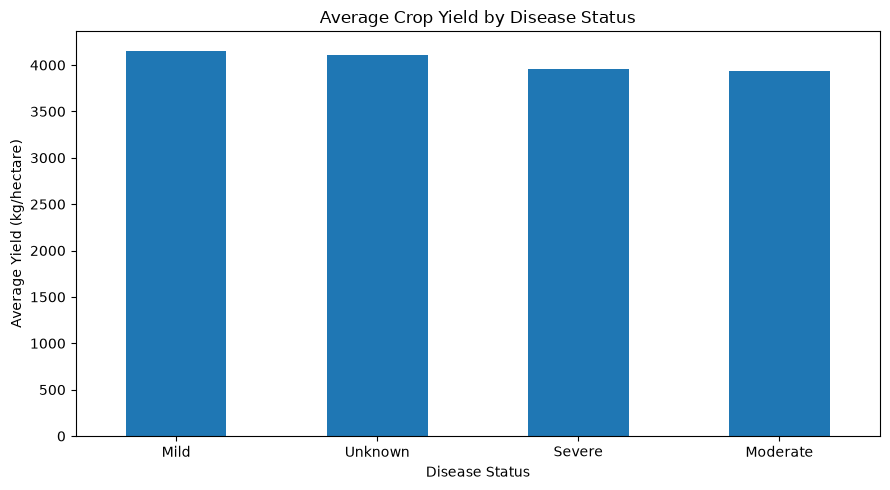

In [41]:
disease_columns = [
    "cat__crop_disease_status_Mild",
    "cat__crop_disease_status_Moderate",
    "cat__crop_disease_status_Severe",
    "cat__crop_disease_status_Unknown"
]

disease_yield = {}

for column in disease_columns:
    disease_name = column.replace("cat__crop_disease_status_", "")
    
    disease_data = df[df[column] == 1]
    
    disease_yield[disease_name] = disease_data[TARGET].mean()

disease_yield = pd.Series(disease_yield).sort_values(ascending=False)

print("Average Yield by Crop Disease Status")
print("=" * 45)
print(disease_yield)

# Visualization
plt.figure(figsize=(9, 5))

disease_yield.plot(kind="bar")

plt.title("Average Crop Yield by Disease Status")
plt.xlabel("Disease Status")
plt.ylabel("Average Yield (kg/hectare)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [42]:
print("========== EDA SUMMARY ==========\n")

print("1. Dataset:")
print(f"   - Rows: {df.shape[0]}")
print(f"   - Columns: {df.shape[1]}")
print("   - Missing values: None")
print("   - Duplicate rows: None")

print("\n2. Target Variable:")
print(f"   - Target: {TARGET}")
print(f"   - Mean yield: {df[TARGET].mean():.2f} kg/hectare")
print(f"   - Median yield: {df[TARGET].median():.2f} kg/hectare")
print(f"   - Minimum yield: {df[TARGET].min():.2f} kg/hectare")
print(f"   - Maximum yield: {df[TARGET].max():.2f} kg/hectare")

print("\n3. Numerical Feature Correlations:")
print("   - Strongest positive:")
print(f"     {correlations.drop(TARGET).idxmax()} "
      f"({correlations.drop(TARGET).max():.3f})")

print("   - Strongest negative:")
print(f"     {correlations.drop(TARGET).idxmin()} "
      f"({correlations.drop(TARGET).min():.3f})")

print("\n4. Crop Analysis:")
print(f"   - Highest average yield: {crop_yield.idxmax()}")
print(f"   - Lowest average yield: {crop_yield.idxmin()}")

print("\n5. Region Analysis:")
print(f"   - Highest average yield: {region_yield.idxmax()}")
print(f"   - Lowest average yield: {region_yield.idxmin()}")

print("\n6. Irrigation Analysis:")
print(f"   - Highest average yield: {irrigation_yield.idxmax()}")
print(f"   - Lowest average yield: {irrigation_yield.idxmin()}")

print("\n7. Fertilizer Analysis:")
print(f"   - Highest average yield: {fertilizer_yield.idxmax()}")
print(f"   - Lowest average yield: {fertilizer_yield.idxmin()}")

print("\n8. Disease Status Analysis:")
print(f"   - Highest average yield: {disease_yield.idxmax()}")
print(f"   - Lowest average yield: {disease_yield.idxmin()}")

print("\n========== EDA COMPLETED ==========")

========== EDA SUMMARY ==========

1. Dataset:
   - Rows: 400
   - Columns: 39
   - Missing values: None
   - Duplicate rows: None

2. Target Variable:
   - Target: yield_kg_per_hectare
   - Mean yield: 4037.78 kg/hectare
   - Median yield: 4071.69 kg/hectare
   - Minimum yield: 2023.56 kg/hectare
   - Maximum yield: 5998.29 kg/hectare

3. Numerical Feature Correlations:
   - Strongest positive:
     num__pesticide_usage_ml (0.060)
   - Strongest negative:
     num__soil_moisture_% (-0.110)

4. Crop Analysis:
   - Highest average yield: Soybean
   - Lowest average yield: Rice

5. Region Analysis:
   - Highest average yield: South India
   - Lowest average yield: South USA

6. Irrigation Analysis:
   - Highest average yield: Drip
   - Lowest average yield: Unknown

7. Fertilizer Analysis:
   - Highest average yield: Inorganic
   - Lowest average yield: Mixed

8. Disease Status Analysis:
   - Highest average yield: Mild
   - Lowest average yield: Moderate

========== EDA COMPLETED ======

YIELDSENSEAI - EXPLORATORY DATA ANALYSIS

Dataset loaded successfully!
Shape: (400, 39)

1. DATASET INFORMATION

Column Names:
['num__soil_moisture_%', 'num__soil_pH', 'num__temperature_C', 'num__rainfall_mm', 'num__humidity_%', 'num__sunlight_hours', 'num__pesticide_usage_ml', 'num__total_days', 'num__latitude', 'num__longitude', 'num__NDVI_index', 'num__sowing_month', 'num__sowing_day', 'num__observation_month', 'num__observation_day', 'num__days_since_sowing', 'num__crop_cycle_progress', 'cat__region_Central USA', 'cat__region_East Africa', 'cat__region_North India', 'cat__region_South India', 'cat__region_South USA', 'cat__crop_type_Cotton', 'cat__crop_type_Maize', 'cat__crop_type_Rice', 'cat__crop_type_Soybean', 'cat__crop_type_Wheat', 'cat__irrigation_type_Drip', 'cat__irrigation_type_Manual', 'cat__irrigation_type_Sprinkler', 'cat__irrigation_type_Unknown', 'cat__fertilizer_type_Inorganic', 'cat__fertilizer_type_Mixed', 'cat__fertilizer_type_Organic', 'cat__crop_disease_status_M

,num__soil_moisture_%,num__soil_pH,num__temperature_C,num__rainfall_mm,num__humidity_%,num__sunlight_hours,num__pesticide_usage_ml,num__total_days,num__latitude,num__longitude,num__NDVI_index,num__sowing_month,num__sowing_day,num__observation_month,num__observation_day,num__days_since_sowing,num__crop_cycle_progress,cat__region_Central USA,cat__region_East Africa,cat__region_North India,cat__region_South India,cat__region_South USA,cat__crop_type_Cotton,cat__crop_type_Maize,cat__crop_type_Rice,cat__crop_type_Soybean,cat__crop_type_Wheat,cat__irrigation_type_Drip,cat__irrigation_type_Manual,cat__irrigation_type_Sprinkler,cat__irrigation_type_Unknown,cat__fertilizer_type_Inorganic,cat__fertilizer_type_Mixed,cat__fertilizer_type_Organic,cat__crop_disease_status_Mild,cat__crop_disease_status_Moderate,cat__crop_disease_status_Severe,cat__crop_disease_status_Unknown,yield_kg_per_hectare
0,-0.040920,-1.142586,1.367436,1.003676,1.095936,-1.362615,1.037584,1.032160,-0.111927,0.855939,0.059879,-0.085195,-0.755265,-0.653135,1.564841,-0.278372,-0.474713,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,5978.14
1,1.195373,1.119875,-0.240630,-1.213385,0.380093,-0.257852,-0.994233,-0.275124,-0.876690,1.193662,-0.803756,1.131876,-1.250116,-0.653135,-0.783888,-1.529484,-1.595235,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,4794.58
2,-0.988144,1.359834,-0.487590,1.015080,1.242915,-1.000300,-0.493574,-0.750500,-0.323423,1.568930,0.117454,-1.302266,1.347848,-0.653135,1.682277,0.138665,0.370556,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3404.58
3,-0.166950,-1.039747,1.691689,1.452179,1.387172,1.405231,-1.489518,1.151004,0.131146,-0.133806,1.038664,-0.085195,1.224136,1.311180,-0.549015,1.334172,0.961347,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,4016.87
4,1.449434,1.531232,1.037528,1.618507,0.546805,1.054796,0.753468,1.626380,-1.301434,-1.675705,0.405332,1.131876,0.234435,2.620723,-1.371071,2.251654,1.596415,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,2160.32



2. MISSING VALUE ANALYSIS
No missing values found!

3. DUPLICATE ANALYSIS
Number of duplicate rows: 0
No duplicate rows found!

4. TARGET VARIABLE ANALYSIS
Target variable: yield_kg_per_hectare

Target Statistics:
count     400.000000
mean     4037.775650
std      1174.194159
min      2023.560000
25%      3020.495000
50%      4071.690000
75%      5076.812500
max      5998.290000
Name: yield_kg_per_hectare, dtype: float64

Target Mean: 4037.78
Target Median: 4071.69
Target Minimum: 2023.56
Target Maximum: 5998.29


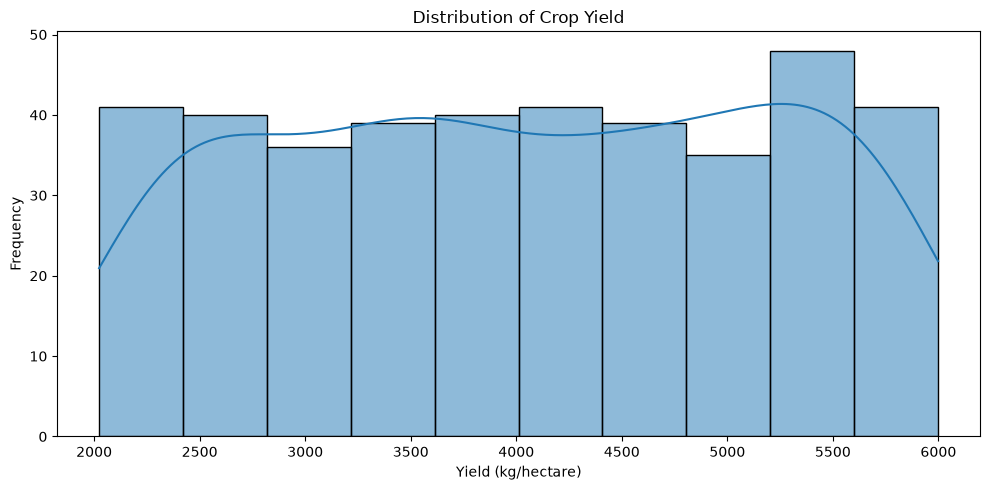

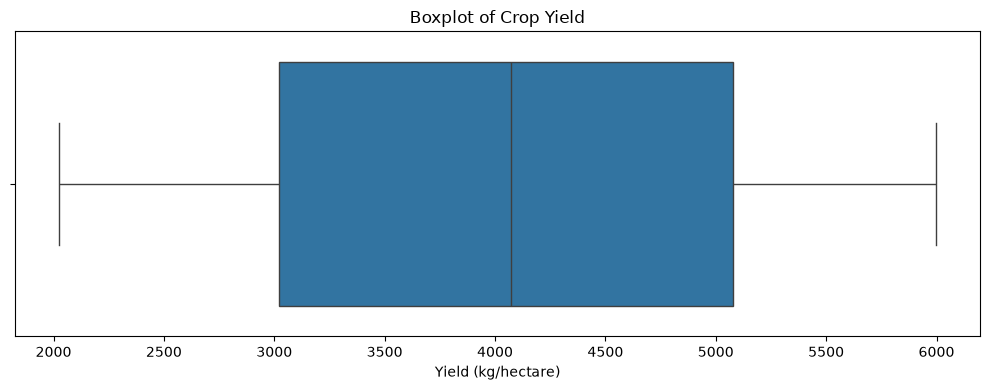


5. FEATURE INFORMATION

Number of input features: 38
Numerical features: 38

Generating feature distribution plots...


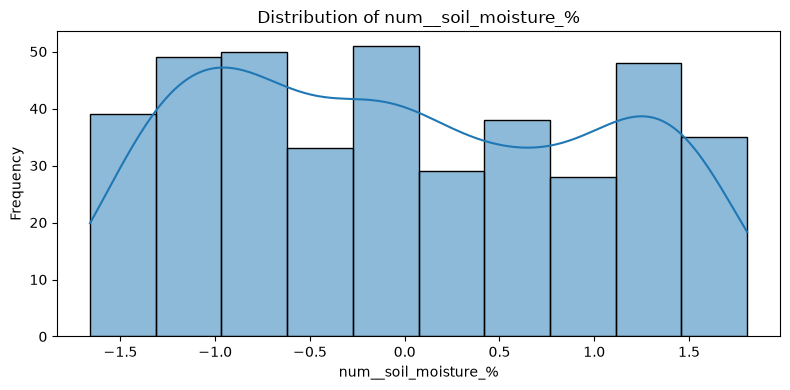

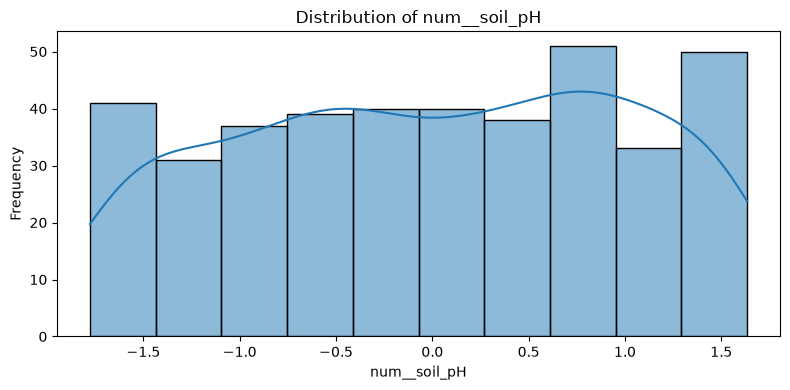

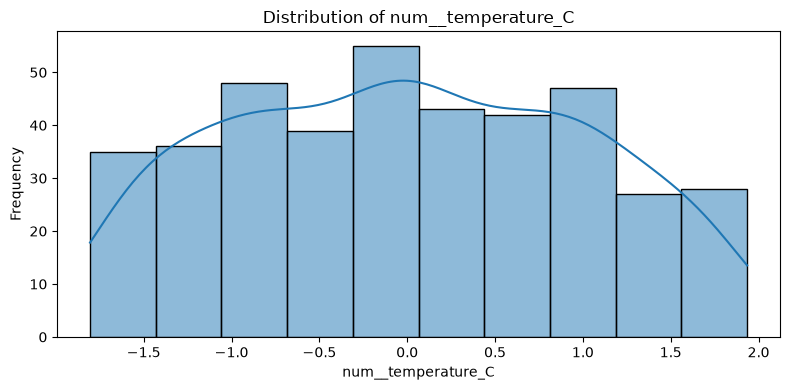

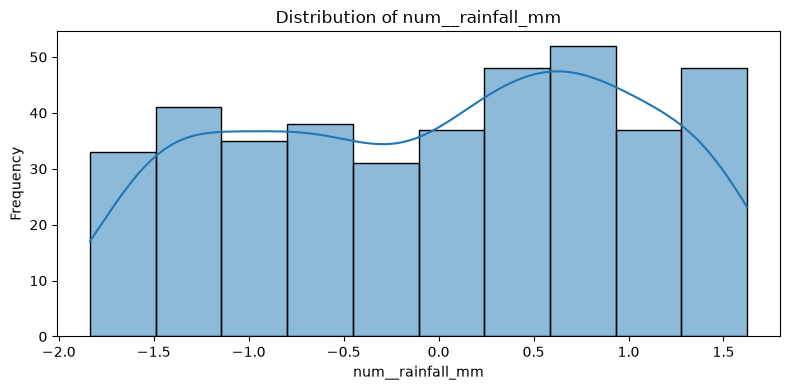

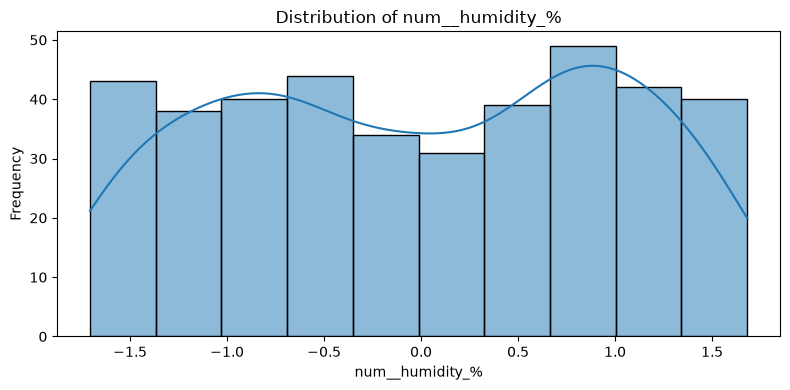

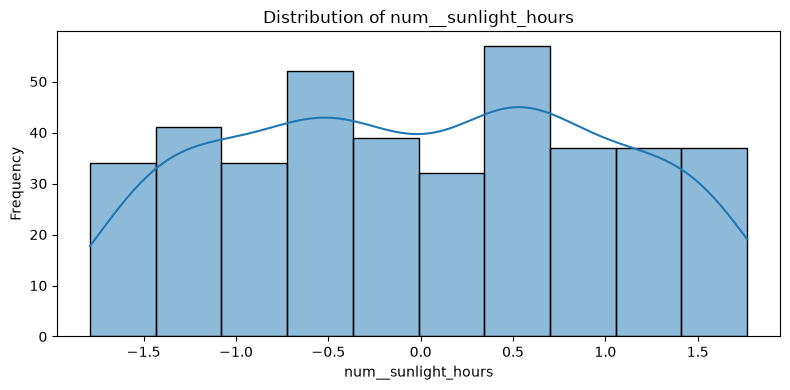

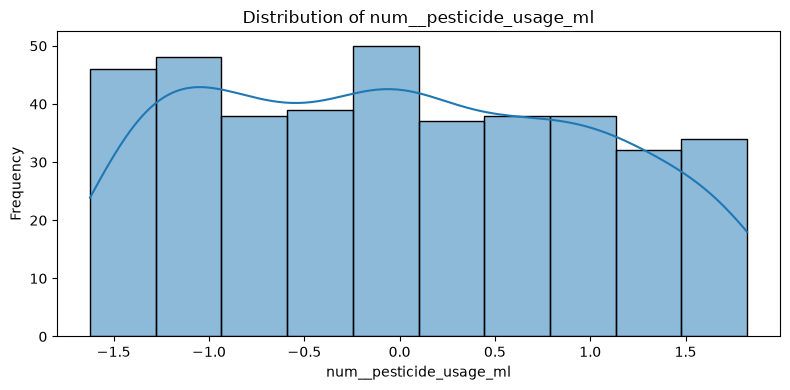

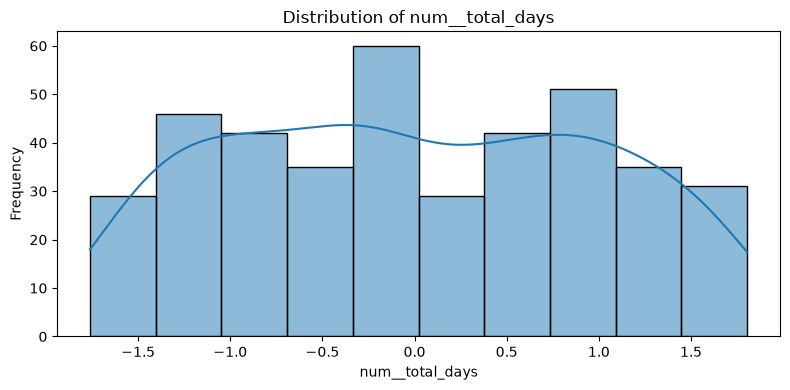

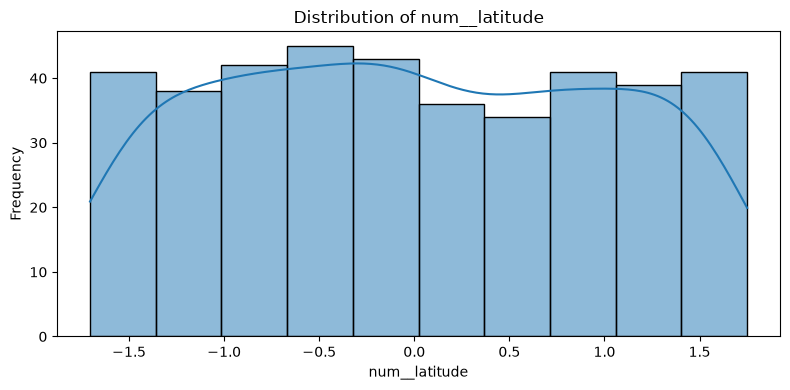

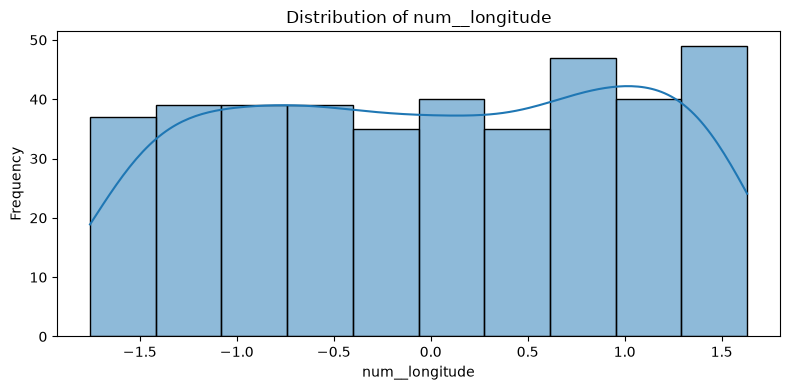

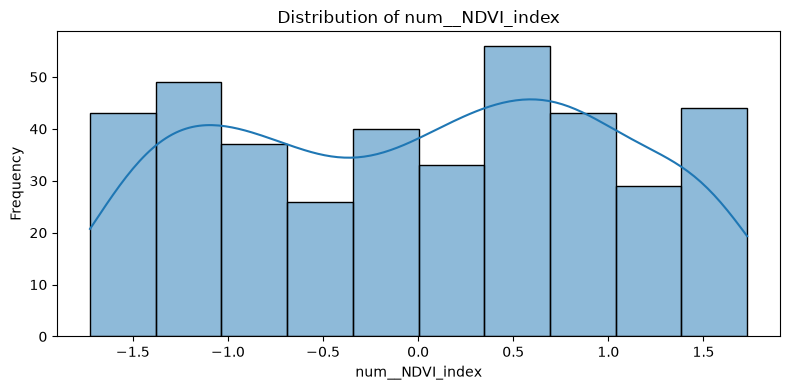

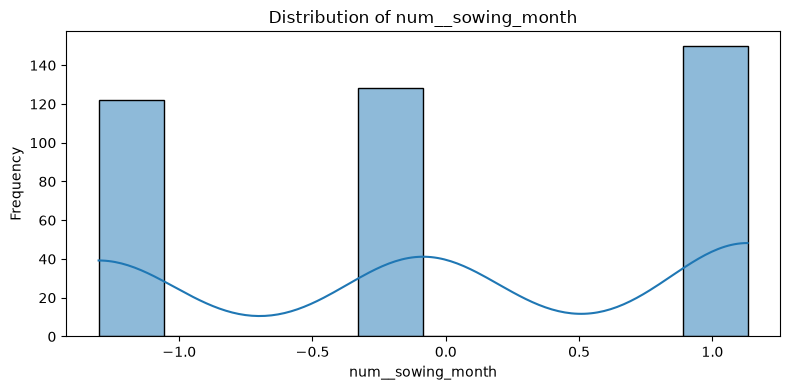

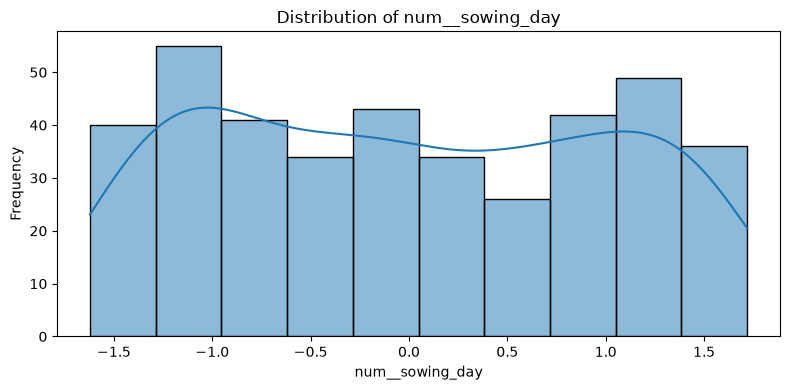

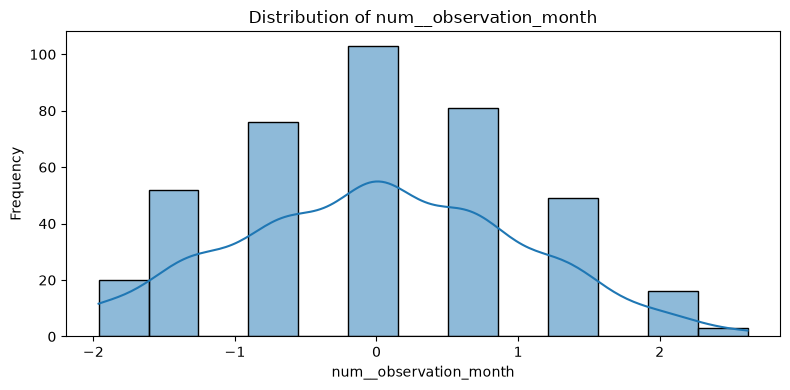

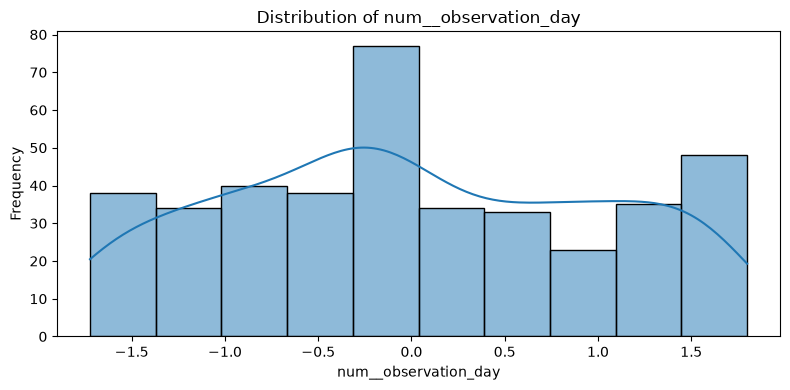

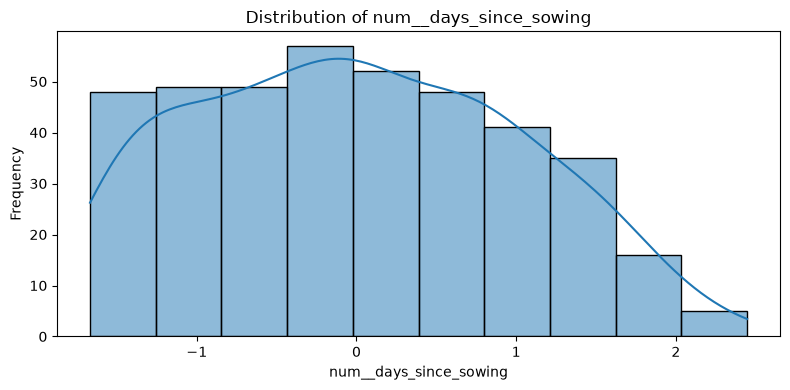

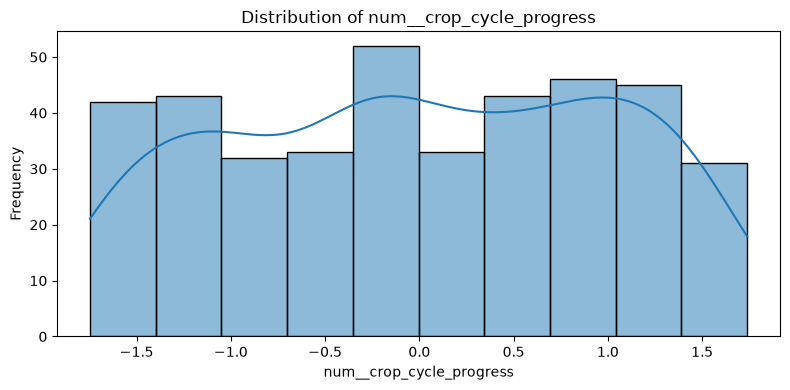


6. CORRELATION WITH CROP YIELD

Correlation of features with crop yield:


yield_kg_per_hectare                 1.000000
cat__crop_type_Soybean               0.113758
cat__region_South India              0.060920
num__pesticide_usage_ml              0.059906
num__NDVI_index                      0.059072
cat__crop_disease_status_Mild        0.056966
num__soil_pH                         0.040621
cat__crop_disease_status_Unknown     0.036573
cat__irrigation_type_Drip            0.028595
num__crop_cycle_progress             0.027484
cat__fertilizer_type_Inorganic       0.022643
cat__region_East Africa              0.019974
num__total_days                      0.018986
num__days_since_sowing               0.018970
num__temperature_C                   0.018301
num__observation_month               0.015748
cat__irrigation_type_Sprinkler       0.014284
num__humidity_%                      0.013654
cat__irrigation_type_Manual          0.011858
cat__fertilizer_type_Organic         0.006544
cat__crop_type_Wheat                 0.005201
num__sunlight_hours               


Strongest positive correlation:
cat__crop_type_Soybean -> 0.114

Strongest negative correlation:
num__soil_moisture_% -> -0.11


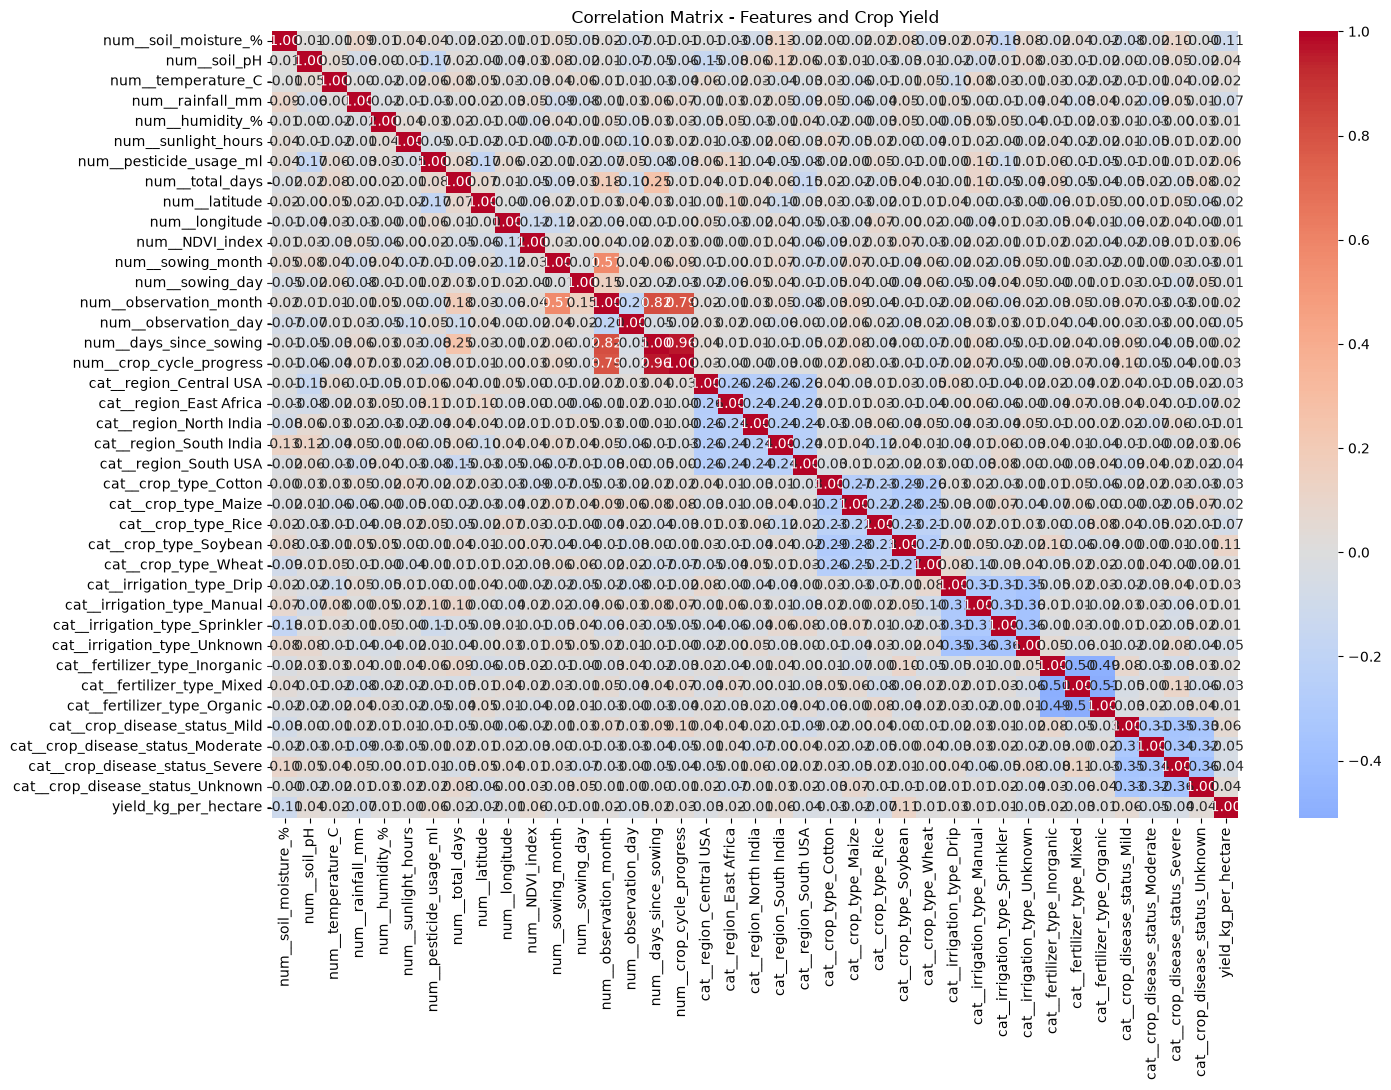


7. CROP-WISE YIELD ANALYSIS

Average Yield by Crop:


Soybean    4285.368778
Wheat      4050.167564
Maize      3988.334819
Cotton     3960.876023
Rice       3834.838033
dtype: float64

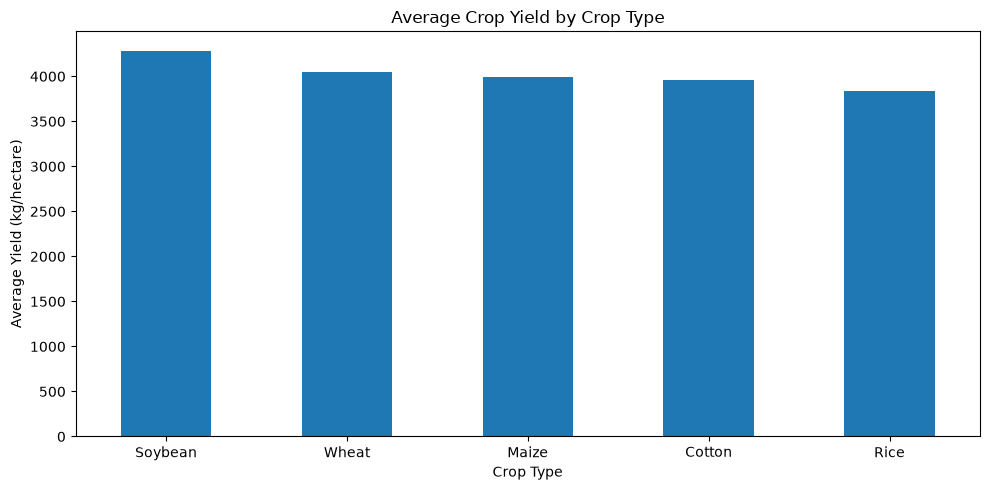


8. REGION-WISE YIELD ANALYSIS

Average Yield by Region:


South India    4182.933462
East Africa    4084.993165
North India    4005.176104
Central USA    3976.988409
South USA      3945.557051
dtype: float64

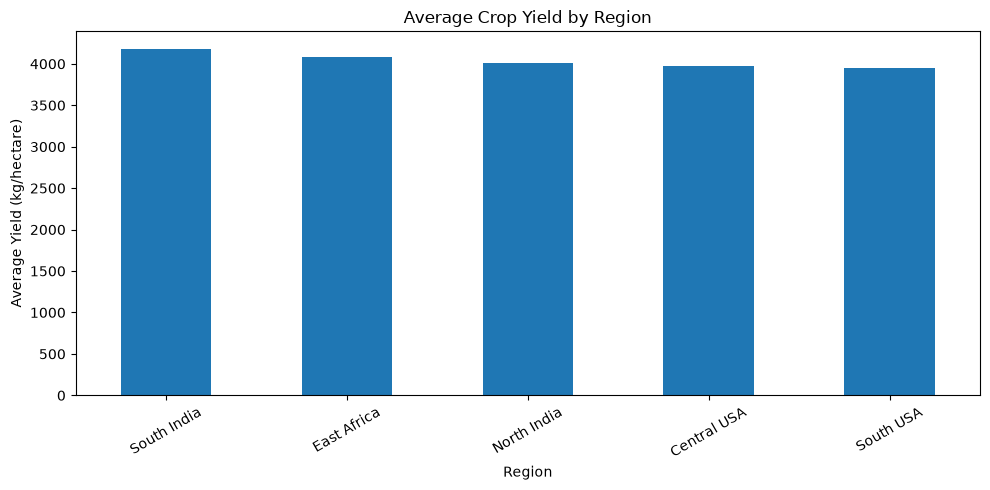


9. IRRIGATION-WISE YIELD ANALYSIS

Average Yield by Irrigation Type:


Drip         4099.133478
Sprinkler    4067.585417
Manual       4062.692105
Unknown      3944.837863
dtype: float64

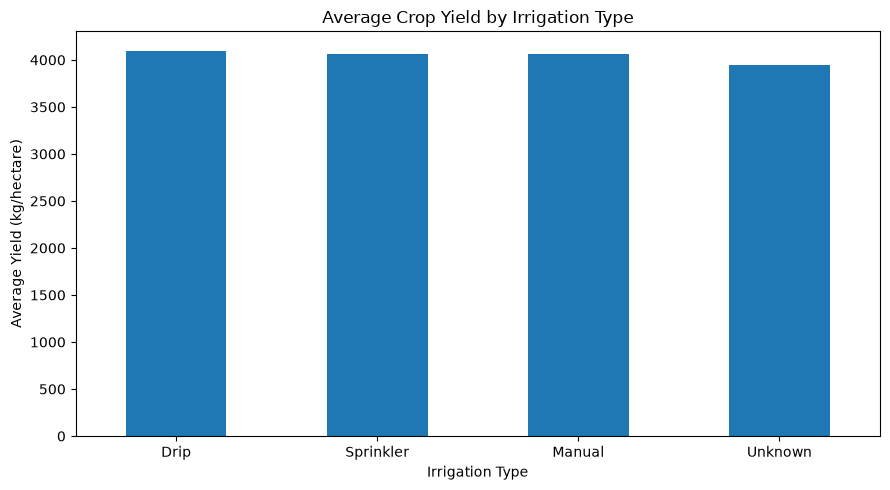


10. FERTILIZER-WISE YIELD ANALYSIS

Average Yield by Fertilizer Type:


Inorganic    4076.044769
Organic      4048.587910
Mixed        3990.541618
dtype: float64

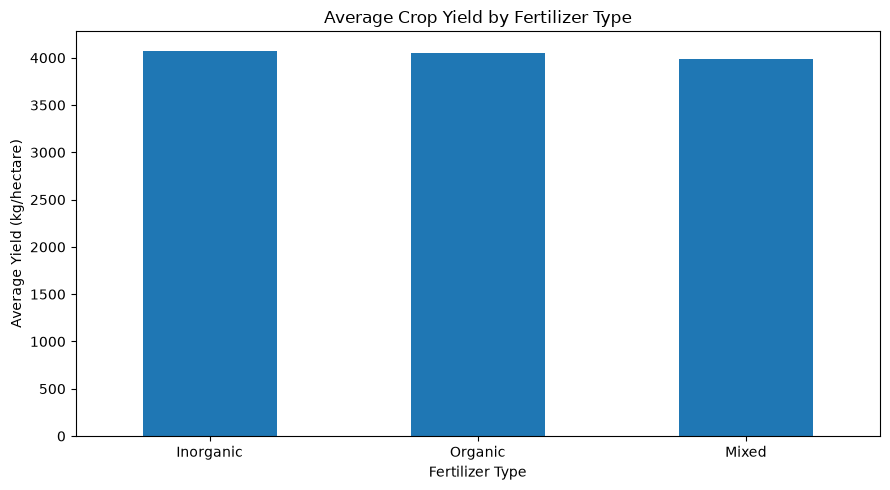


11. DISEASE STATUS VS YIELD

Average Yield by Disease Status:


Mild        4155.847835
Unknown     4111.571584
Severe      3953.679266
Moderate    3933.045699
dtype: float64

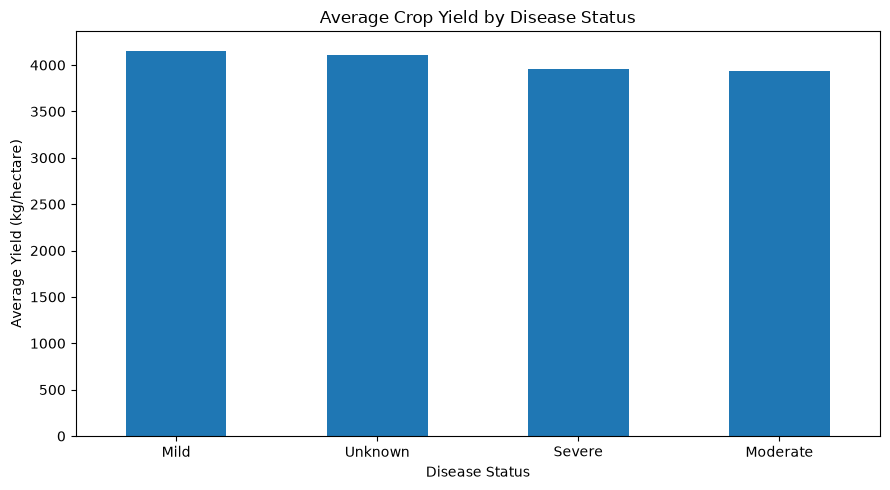


12. FINAL EDA SUMMARY

Dataset:
- Rows: 400
- Columns: 39
- Missing values: 0
- Duplicate rows: 0

Target:
- Target variable: yield_kg_per_hectare
- Mean yield: 4037.78 kg/hectare
- Median yield: 4071.69 kg/hectare
- Minimum yield: 2023.56 kg/hectare
- Maximum yield: 5998.29 kg/hectare

Correlation:
- Strongest positive: cat__crop_type_Soybean
  (0.114)

- Strongest negative: num__soil_moisture_%
  (-0.110)

Crop:
- Highest average yield: Soybean
- Lowest average yield: Rice

Region:
- Highest average yield: South India
- Lowest average yield: South USA

Irrigation:
- Highest average yield: Drip
- Lowest average yield: Unknown

Fertilizer:
- Highest average yield: Inorganic
- Lowest average yield: Mixed

Disease Status:
- Highest average yield: Mild
- Lowest average yield: Moderate

EDA COMPLETED SUCCESSFULLY


In [43]:
# ============================================================
# YieldSenseAI - COMPLETE EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------------------
# 1. LOAD PROCESSED TRAINING DATA
# ------------------------------------------------------------

DATA_PATH = "../data/processed/train_processed.csv"
TARGET = "yield_kg_per_hectare"

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("YIELDSENSEAI - EXPLORATORY DATA ANALYSIS")
print("=" * 70)

print("\nDataset loaded successfully!")
print(f"Shape: {df.shape}")


# ------------------------------------------------------------
# 2. BASIC DATASET INFORMATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("1. DATASET INFORMATION")
print("=" * 70)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Info:")
df.info()

print("\nFirst 5 Rows:")
display(df.head())


# ------------------------------------------------------------
# 3. MISSING VALUES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("2. MISSING VALUE ANALYSIS")
print("=" * 70)

missing_values = df.isnull().sum()

if missing_values.sum() == 0:
    print("No missing values found!")
else:
    print(missing_values[missing_values > 0])


# ------------------------------------------------------------
# 4. DUPLICATE VALUES
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("3. DUPLICATE ANALYSIS")
print("=" * 70)

duplicates = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicates}")

if duplicates == 0:
    print("No duplicate rows found!")


# ------------------------------------------------------------
# 5. TARGET VARIABLE ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("4. TARGET VARIABLE ANALYSIS")
print("=" * 70)

print(f"Target variable: {TARGET}")

print("\nTarget Statistics:")
print(df[TARGET].describe())

print("\nTarget Mean:", round(df[TARGET].mean(), 2))
print("Target Median:", round(df[TARGET].median(), 2))
print("Target Minimum:", round(df[TARGET].min(), 2))
print("Target Maximum:", round(df[TARGET].max(), 2))


# ------------------------------------------------------------
# 6. TARGET DISTRIBUTION
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

sns.histplot(df[TARGET], kde=True)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (kg/hectare)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 7. TARGET BOXPLOT / OUTLIER ANALYSIS
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

sns.boxplot(x=df[TARGET])

plt.title("Boxplot of Crop Yield")
plt.xlabel("Yield (kg/hectare)")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 8. NUMERICAL FEATURE IDENTIFICATION
# ------------------------------------------------------------

feature_columns = [col for col in df.columns if col != TARGET]

numerical_features = df[feature_columns].select_dtypes(
    include=np.number
).columns.tolist()

print("\n" + "=" * 70)
print("5. FEATURE INFORMATION")
print("=" * 70)

print(f"\nNumber of input features: {len(feature_columns)}")
print(f"Numerical features: {len(numerical_features)}")


# ------------------------------------------------------------
# 9. FEATURE DISTRIBUTIONS
# ------------------------------------------------------------

print("\nGenerating feature distribution plots...")

# Exclude one-hot encoded columns from this visualization
# so that only meaningful continuous numerical variables are shown.

continuous_features = [
    col for col in numerical_features
    if not col.startswith("cat__")
]

if len(continuous_features) > 0:

    for feature in continuous_features:

        plt.figure(figsize=(8, 4))

        sns.histplot(df[feature], kde=True)

        plt.title(f"Distribution of {feature}")
        plt.xlabel(feature)
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()


# ------------------------------------------------------------
# 10. CORRELATION WITH TARGET
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("6. CORRELATION WITH CROP YIELD")
print("=" * 70)

correlations = (
    df[numerical_features + [TARGET]]
    .corr()[TARGET]
    .sort_values(ascending=False)
)

print("\nCorrelation of features with crop yield:")
display(correlations)


# Strongest positive and negative relationships
feature_correlations = correlations.drop(TARGET)

print("\nStrongest positive correlation:")
print(
    feature_correlations.idxmax(),
    "->",
    round(feature_correlations.max(), 3)
)

print("\nStrongest negative correlation:")
print(
    feature_correlations.idxmin(),
    "->",
    round(feature_correlations.min(), 3)
)


# ------------------------------------------------------------
# 11. CORRELATION HEATMAP
# ------------------------------------------------------------

plt.figure(figsize=(15, 11))

corr_matrix = df[numerical_features + [TARGET]].corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - Features and Crop Yield")

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 12. CROP-WISE YIELD ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("7. CROP-WISE YIELD ANALYSIS")
print("=" * 70)

crop_columns = [
    col for col in df.columns
    if col.startswith("cat__crop_type_")
]

crop_yield = {}

for column in crop_columns:

    crop_name = column.replace("cat__crop_type_", "")

    crop_data = df[df[column] == 1]

    if len(crop_data) > 0:
        crop_yield[crop_name] = crop_data[TARGET].mean()

crop_yield = pd.Series(crop_yield).sort_values(ascending=False)

print("\nAverage Yield by Crop:")
display(crop_yield)

plt.figure(figsize=(10, 5))

crop_yield.plot(kind="bar")

plt.title("Average Crop Yield by Crop Type")
plt.xlabel("Crop Type")
plt.ylabel("Average Yield (kg/hectare)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 13. REGION-WISE YIELD ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("8. REGION-WISE YIELD ANALYSIS")
print("=" * 70)

region_columns = [
    col for col in df.columns
    if col.startswith("cat__region_")
]

region_yield = {}

for column in region_columns:

    region_name = column.replace("cat__region_", "")

    region_data = df[df[column] == 1]

    if len(region_data) > 0:
        region_yield[region_name] = region_data[TARGET].mean()

region_yield = pd.Series(region_yield).sort_values(ascending=False)

print("\nAverage Yield by Region:")
display(region_yield)

plt.figure(figsize=(10, 5))

region_yield.plot(kind="bar")

plt.title("Average Crop Yield by Region")
plt.xlabel("Region")
plt.ylabel("Average Yield (kg/hectare)")
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 14. IRRIGATION-WISE YIELD ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("9. IRRIGATION-WISE YIELD ANALYSIS")
print("=" * 70)

irrigation_columns = [
    col for col in df.columns
    if col.startswith("cat__irrigation_type_")
]

irrigation_yield = {}

for column in irrigation_columns:

    irrigation_name = column.replace(
        "cat__irrigation_type_", ""
    )

    irrigation_data = df[df[column] == 1]

    if len(irrigation_data) > 0:
        irrigation_yield[irrigation_name] = (
            irrigation_data[TARGET].mean()
        )

irrigation_yield = pd.Series(
    irrigation_yield
).sort_values(ascending=False)

print("\nAverage Yield by Irrigation Type:")
display(irrigation_yield)

plt.figure(figsize=(9, 5))

irrigation_yield.plot(kind="bar")

plt.title("Average Crop Yield by Irrigation Type")
plt.xlabel("Irrigation Type")
plt.ylabel("Average Yield (kg/hectare)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 15. FERTILIZER-WISE YIELD ANALYSIS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("10. FERTILIZER-WISE YIELD ANALYSIS")
print("=" * 70)

fertilizer_columns = [
    col for col in df.columns
    if col.startswith("cat__fertilizer_type_")
]

fertilizer_yield = {}

for column in fertilizer_columns:

    fertilizer_name = column.replace(
        "cat__fertilizer_type_", ""
    )

    fertilizer_data = df[df[column] == 1]

    if len(fertilizer_data) > 0:
        fertilizer_yield[fertilizer_name] = (
            fertilizer_data[TARGET].mean()
        )

fertilizer_yield = pd.Series(
    fertilizer_yield
).sort_values(ascending=False)

print("\nAverage Yield by Fertilizer Type:")
display(fertilizer_yield)

plt.figure(figsize=(9, 5))

fertilizer_yield.plot(kind="bar")

plt.title("Average Crop Yield by Fertilizer Type")
plt.xlabel("Fertilizer Type")
plt.ylabel("Average Yield (kg/hectare)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 16. DISEASE STATUS VS YIELD
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("11. DISEASE STATUS VS YIELD")
print("=" * 70)

disease_columns = [
    col for col in df.columns
    if col.startswith("cat__crop_disease_status_")
]

disease_yield = {}

for column in disease_columns:

    disease_name = column.replace(
        "cat__crop_disease_status_", ""
    )

    disease_data = df[df[column] == 1]

    if len(disease_data) > 0:
        disease_yield[disease_name] = (
            disease_data[TARGET].mean()
        )

disease_yield = pd.Series(
    disease_yield
).sort_values(ascending=False)

print("\nAverage Yield by Disease Status:")
display(disease_yield)

plt.figure(figsize=(9, 5))

disease_yield.plot(kind="bar")

plt.title("Average Crop Yield by Disease Status")
plt.xlabel("Disease Status")
plt.ylabel("Average Yield (kg/hectare)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 17. FINAL EDA SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("12. FINAL EDA SUMMARY")
print("=" * 70)

print(f"""
Dataset:
- Rows: {df.shape[0]}
- Columns: {df.shape[1]}
- Missing values: {df.isnull().sum().sum()}
- Duplicate rows: {df.duplicated().sum()}

Target:
- Target variable: {TARGET}
- Mean yield: {df[TARGET].mean():.2f} kg/hectare
- Median yield: {df[TARGET].median():.2f} kg/hectare
- Minimum yield: {df[TARGET].min():.2f} kg/hectare
- Maximum yield: {df[TARGET].max():.2f} kg/hectare

Correlation:
- Strongest positive: {feature_correlations.idxmax()}
  ({feature_correlations.max():.3f})

- Strongest negative: {feature_correlations.idxmin()}
  ({feature_correlations.min():.3f})

Crop:
- Highest average yield: {crop_yield.idxmax()}
- Lowest average yield: {crop_yield.idxmin()}

Region:
- Highest average yield: {region_yield.idxmax()}
- Lowest average yield: {region_yield.idxmin()}

Irrigation:
- Highest average yield: {irrigation_yield.idxmax()}
- Lowest average yield: {irrigation_yield.idxmin()}

Fertilizer:
- Highest average yield: {fertilizer_yield.idxmax()}
- Lowest average yield: {fertilizer_yield.idxmin()}

Disease Status:
- Highest average yield: {disease_yield.idxmax()}
- Lowest average yield: {disease_yield.idxmin()}
""")

print("=" * 70)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 70)